# Variable sine wave oscillator

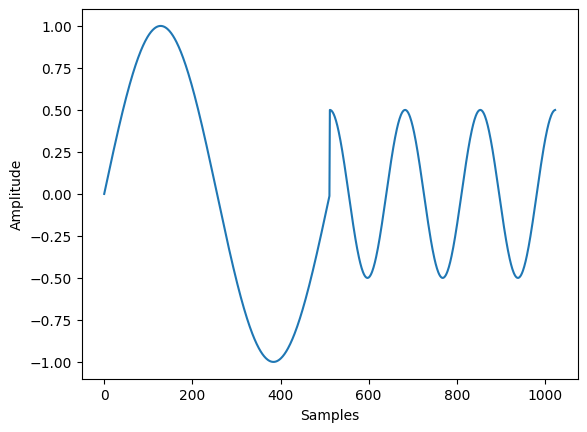

In [10]:
import matplotlib.pyplot as plt

from engine.oscillator import SineOscillator

osc = SineOscillator(freq=1, amp=1, phase=0, sample_rate=512)
samples1 = osc.get_samples(n=512)

# changing parameters of the oscillator and get additional samples
osc.freq = 3
osc.amp = 0.5
osc.phase = 90
samples2 = osc.get_samples(n=512)
samples = samples1 + samples2

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()

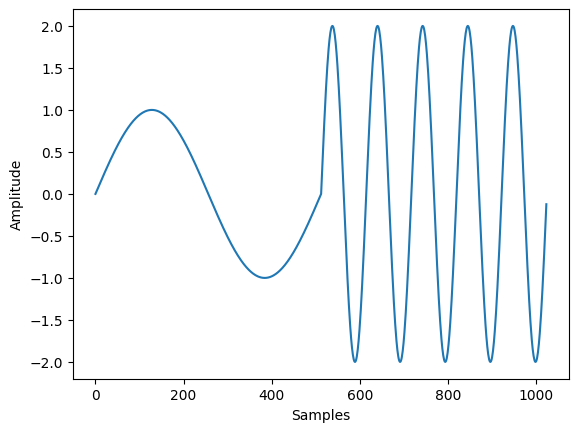

In [11]:
import matplotlib.pyplot as plt

osc2 = SineOscillator(freq=1, amp=1, phase=0, sample_rate=512)
samples2_1 = osc2.get_samples(n=512)
osc2.amp = 2
osc2.freq = 5
osc2.phase = 0
samples2_2 = osc2.get_samples(n=512)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples2_1 + samples2_2)
plt.show()

## Variable square wave oscillator

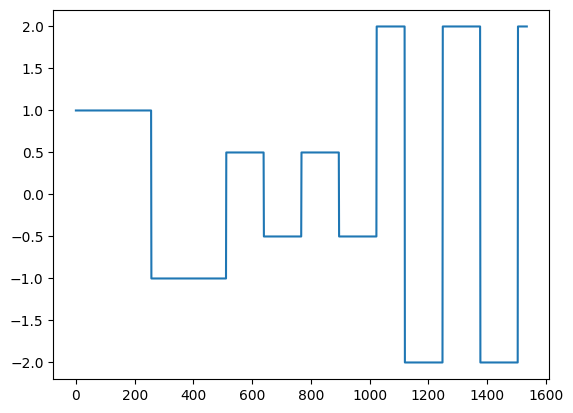

In [12]:
from engine.oscillator import SquareOscillator

osc = SquareOscillator(freq=1, amp=1, phase=0, sample_rate=512)

# Get 512 samples from the oscillator
samples1 = osc.get_samples(n=512)
osc.freq = 2
osc.amp = 0.5
samples2 = osc.get_samples(n=512)
osc.amp = 2
osc.phase = 45
samples3 = osc.get_samples(n=512)
samples = samples1 + samples2 + samples3
plt.plot(samples)
plt.show()

## Variable Square wave frequency sweep

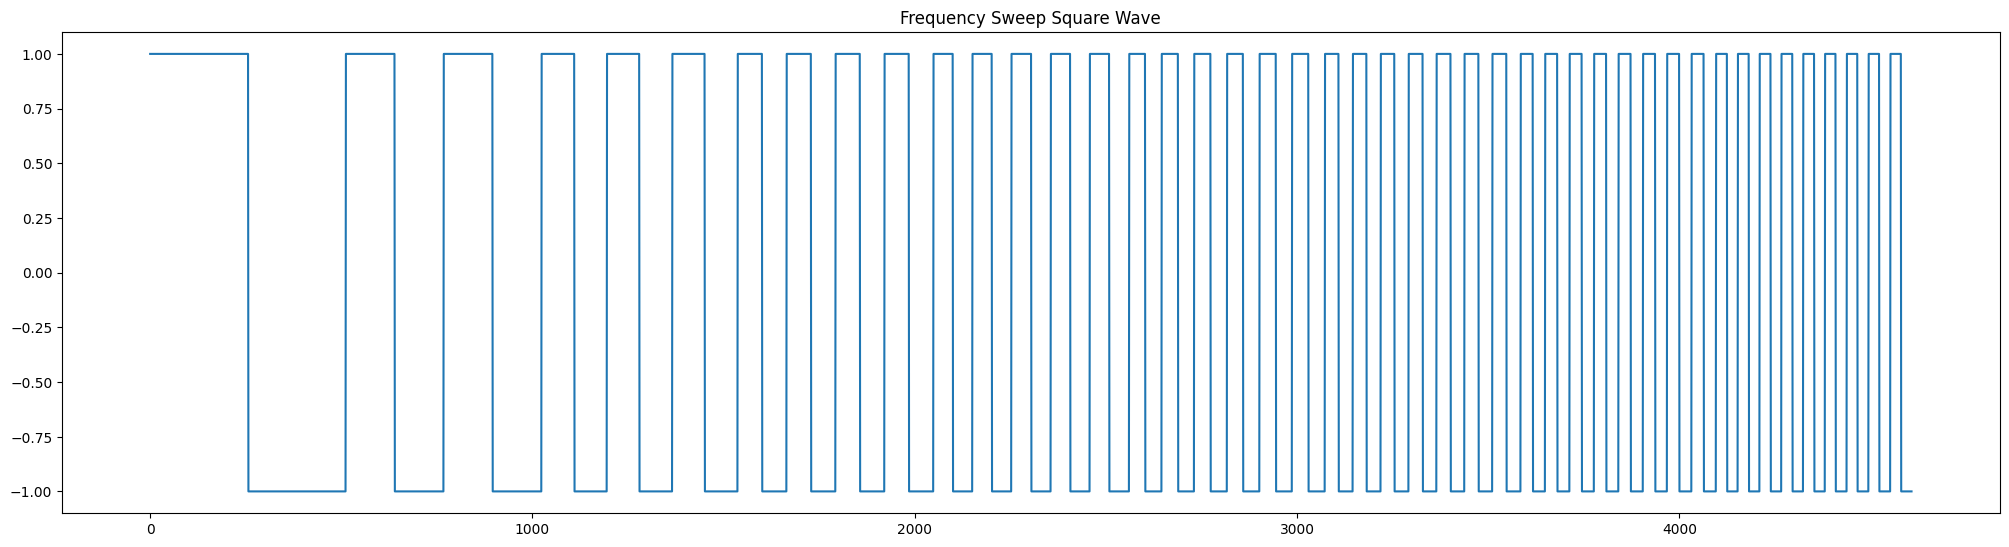

In [13]:
import matplotlib.pyplot as plt


def plot_osc(osc, name=""):
    _ = plt.figure(figsize=(25, 6.25))
    plt.title(f"Frequency Sweep {name} Wave")
    oscillator = osc(freq=1, amp=1, phase=0, sample_rate=512)

    s = []
    for f in range(1, 10):
        oscillator.freq = f
        s += oscillator.get_samples(n=512)

    plt.plot(s)


plot_osc(SquareOscillator, "Square")

## Triangle

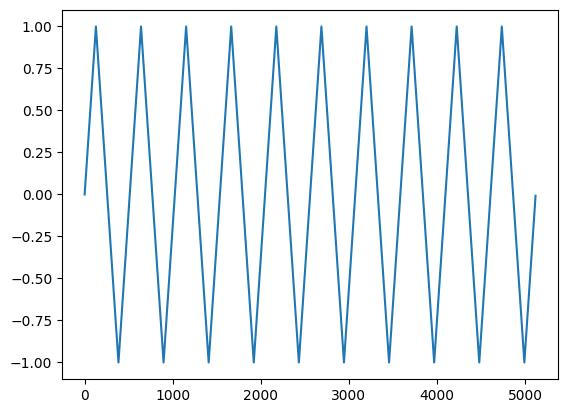

In [14]:
from engine.oscillator import TriangleOscillator

osc = TriangleOscillator(freq=1, amp=1, phase=0, sample_rate=512)
samples = osc.get_samples(n=512 * 10)

plt.plot(samples)
plt.show()

## Sawtooth

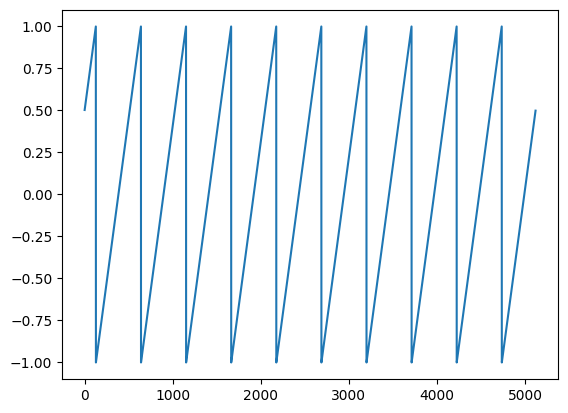

In [15]:
from engine.oscillator import SawtoothOscillator


osc = SawtoothOscillator(freq=1, amp=1, phase=0, sample_rate=512)
samples = osc.get_samples(n=512 * 10)

plt.plot(samples)
plt.show()

## Plotting frequency spectrum

In [16]:
import numpy as np

figsize = (25, 6.25)
colors = "#323031", "#308E91", "#34369D", "#5E2A7E", "#5E2A7E", "#6F3384"


def fplot_xy(wave, fslice=slice(0, 100), sample_rate=44100):
    fd = np.fft.fft(wave)
    fd_mag = np.abs(fd)
    x = np.linspace(0, sample_rate, len(wave))
    y = fd_mag * 2 / sample_rate
    return x[fslice], y[fslice]


def plot(
    xy,
    r=1,
    c=1,
    i=1,
    title="",
    xlabel="",
    ylabel="",
    yticks=None,
    xticks=None,
    **plot_kwargs,
):
    plt.subplot(r, c, i)
    plt.title(title)
    if len(xy) == 2:
        plt.plot(*xy, **plot_kwargs)
    else:
        plt.plot(xy, **plot_kwargs)

    if xticks is not None:
        plt.xticks(xticks)
    if yticks is not None:
        plt.yticks(yticks)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)

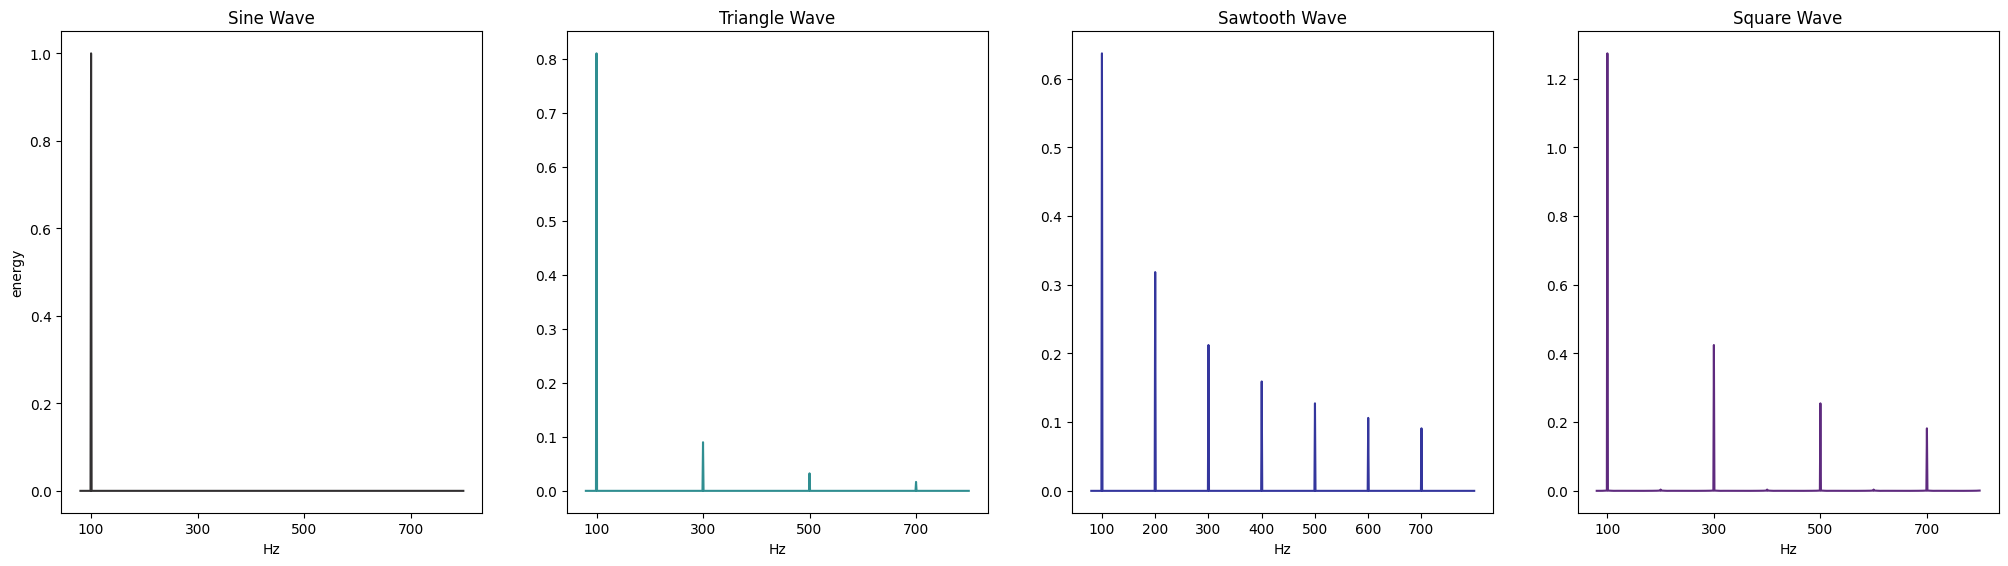

In [17]:
from engine.oscillator import TriangleOscillator, SawtoothOscillator, SquareOscillator

freq = 100
fslice = slice(80, 800)
fig = plt.figure(figsize=figsize)

osc = SineOscillator(freq=freq)
x, y = fplot_xy(osc.get_samples(), fslice)
plot(
    (x, y),
    1,
    4,
    1,
    "Sine Wave",
    "Hz",
    "energy",
    color=colors[0],
    xticks=[100, 300, 500, 700],
)

osc = TriangleOscillator(freq=freq)
x, y = fplot_xy(osc.get_samples(), fslice)
plot(
    (x, y), 1, 4, 2, "Triangle Wave", "Hz", color=colors[1], xticks=[100, 300, 500, 700]
)

osc = SawtoothOscillator(freq=freq)
x, y = fplot_xy(osc.get_samples(), fslice)
plot(
    (x, y),
    1,
    4,
    3,
    "Sawtooth Wave",
    "Hz",
    color=colors[2],
    xticks=[100, 200, 300, 400, 500, 600, 700],
)

osc = SquareOscillator(freq=freq)
x, y = fplot_xy(osc.get_samples(), fslice)
plot((x, y), 1, 4, 4, "Square Wave", "Hz", color=colors[3], xticks=[100, 300, 500, 700])